# Đồ Án Lập Trình Phân Tích Dữ Liệu: Dự báo Độ Mặn ĐBSCL
Nhóm thực hiện: Đỗ Như Minh Hiếu, Trần Tiến Đức, Lê Xuân Hoàng



### 1. Thu thập dữ liệu


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)

df_sal = pd.read_csv('../data/raw/CSDL_DSS1_20240109_1.csv', low_memory=False)
df_sal = df_sal.iloc[1:].copy()
df_sal['Date'] = pd.to_datetime(df_sal['Date'], format='%d/%m/%Y', errors='coerce')
df_sal['Salinity'] = pd.to_numeric(df_sal['Salinity'], errors='coerce')
df_sal['CL'] = pd.to_numeric(df_sal['CL'], errors='coerce')

df_wl = pd.read_csv('../data/raw/WaterLevel/ChauDoc_WaterLevel_2018_2026_15min.csv')
df_wl['ObservationDate'] = pd.to_datetime(df_wl['ObservationDate'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df_wl_daily = df_wl.groupby(df_wl['ObservationDate'].dt.date).agg(WaterLevel_Mean=('WaterLevel', 'mean')).reset_index()
df_wl_daily['ObservationDate'] = pd.to_datetime(df_wl_daily['ObservationDate'])

display(df_sal.head(3))
display(df_wl_daily.tail(3))


,Matram,Kyhieu,longitude,latitude,Z.Elev,Date,pH,Aldrin,BHC,Dieldrin,...,TOC,N_NH4,N_NO3,N_NO2,P_PO4,Coliform,Ecoli,Salinity,TSS,CL
1,QLPH012016,QL1,105.68,9.3,0.66,2016-02-29,8.88,0.021,0.048,0.047,...,17.855,0.163,0.93,0.18,0,1300,92,3.6,4.4,1949.00
2,QLPH012016,QL1,105.68,9.3,0.66,2016-03-15,8.30,0.022,0.021,0.019,...,16.598,0.53,0.88,0.2,0,1100,24,4.6,72.52,271.29
3,QLPH012016,QL1,105.68,9.3,0.66,2016-04-02,7.62,0.02,0.021,0.019,...,13.335,0.129,0.463,0.31,0,1800,22,5.4,115.6,3261.40


,ObservationDate,WaterLevel_Mean
2056,2026-03-09,0.953927
2057,2026-03-10,0.892635
2058,2026-03-11,0.842172


### 2. Làm sạch dữ liệu


In [2]:
print('Số lượng NaN của Salinity:', df_sal['Salinity'].isna().sum())

# Sử dụng công thức Knudsen để nội suy độ mặn
cond_sal_nan = df_sal['Salinity'].isna() & df_sal['CL'].notna()
df_sal.loc[cond_sal_nan, 'Salinity'] = df_sal.loc[cond_sal_nan, 'CL'] * 0.00180665

df_ts = df_sal[df_sal['Kyhieu'] == 'QL1'][['Date', 'Salinity']].copy()
df_ts = df_ts.set_index('Date').resample('D').mean().interpolate(method='linear').dropna()
df_eda = pd.merge(df_ts.reset_index(), df_wl_daily, left_on='Date', right_on='ObservationDate', how='inner').set_index('Date')
df_ts.info()


Số lượng NaN của Salinity: 0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2530 entries, 2015-07-13 to 2022-06-15
Freq: D
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Salinity  2530 non-null   float64
dtypes: float64(1)
memory usage: 39.5 KB


### 3. Khai phá và phân tích dữ liệu (EDA)


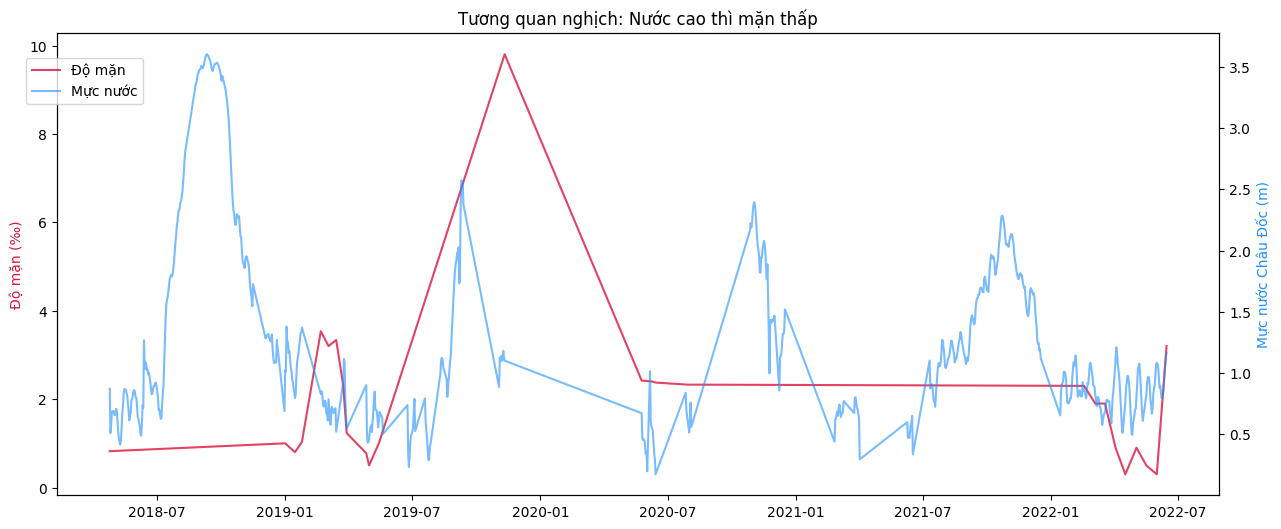

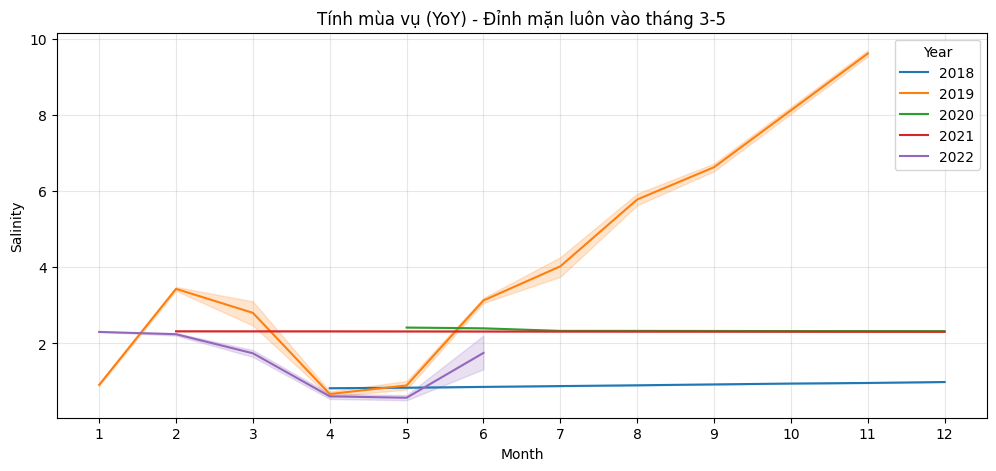

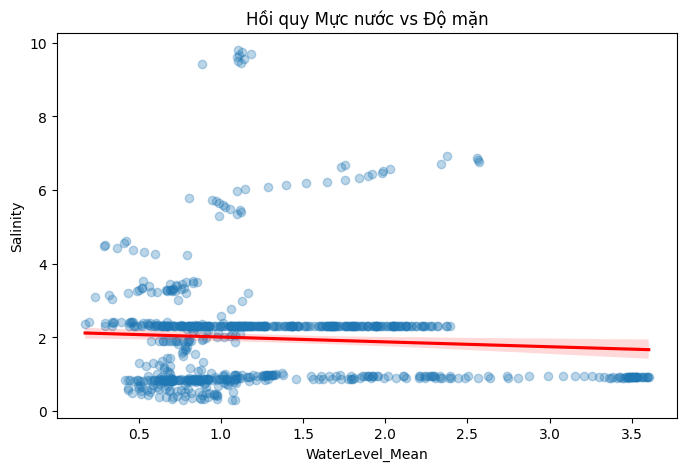

ADF p-value: 0.0041
=> Chuỗi dừng


In [3]:
fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()
ax1.plot(df_eda.index, df_eda['Salinity'], color='crimson', alpha=0.8, label='Độ mặn')
ax2.plot(df_eda.index, df_eda['WaterLevel_Mean'], color='dodgerblue', alpha=0.6, label='Mực nước')
ax1.set_ylabel('Độ mặn (‰)', color='crimson')
ax2.set_ylabel('Mực nước Châu Đốc (m)', color='dodgerblue')
plt.title('Tương quan nghịch: Nước cao thì mặn thấp')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.85))
plt.show()

df_eda['Year'] = df_eda.index.year
df_eda['Month'] = df_eda.index.month
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_eda, x='Month', y='Salinity', hue='Year', palette='tab10')
plt.title('Tính mùa vụ (YoY) - Đỉnh mặn luôn vào tháng 3-5')
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(data=df_eda, x='WaterLevel_Mean', y='Salinity', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Hồi quy Mực nước vs Độ mặn')
plt.show()

from statsmodels.tsa.stattools import adfuller
result = adfuller(df_ts['Salinity'])
print(f'ADF p-value: {result[1]:.4f}')
if result[1] < 0.05:
    print('=> Chuỗi dừng')
else:
    print('=> Chuỗi không dừng')


### 4. Lập mô hình học máy


In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)


### 5. Xây dựng Feature


In [5]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2-lon1)/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

CHAU_DOC_LAT, CHAU_DOC_LON = 10.707, 105.118
df_sal['longitude'] = pd.to_numeric(df_sal['longitude'], errors='coerce')
df_sal['latitude'] = pd.to_numeric(df_sal['latitude'], errors='coerce')
df_sal['Dist'] = haversine_distance(CHAU_DOC_LAT, CHAU_DOC_LON, df_sal['latitude'], df_sal['longitude'])
df_sal['Travel_Time'] = np.round((df_sal['Dist'] * 1.3) / 50.0).fillna(0).astype(int)
df_sal['Target_Date'] = df_sal['Date'] - pd.to_timedelta(df_sal['Travel_Time'], unit='D')

df_merged = pd.merge(df_sal, df_wl_daily, left_on='Target_Date', right_on='ObservationDate', how='left')
df_model = df_merged[df_merged['Kyhieu'] == 'QL1'][['Date', 'Salinity', 'WaterLevel_Mean']].copy()
df_model = df_model.set_index('Date').resample('D').mean().interpolate(method='linear').dropna()

df_model['Lag_1D'] = df_model['Salinity'].shift(1)
df_model['Lag_3D'] = df_model['Salinity'].shift(3)
df_model['Lag_7D'] = df_model['Salinity'].shift(7)
df_model['Month_sin'] = np.sin(2 * np.pi * df_model.index.month / 12)
df_model['Month_cos'] = np.cos(2 * np.pi * df_model.index.month / 12)
df_model = df_model.dropna()

features = ['Lag_1D', 'Lag_3D', 'Lag_7D', 'WaterLevel_Mean', 'Month_sin', 'Month_cos']
split_idx = int(len(df_model) * 0.8)
train_df, test_df = df_model.iloc[:split_idx], df_model.iloc[split_idx:]
X_train, y_train = train_df[features], train_df['Salinity']
X_test, y_test = test_df[features], test_df['Salinity']

print('Train size:', len(train_df))
print('Test size:', len(test_df))


Train size: 992
Test size: 249


### 6. Đánh giá mô hình


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_sarimax = SARIMAX(endog=y_train, exog=X_train[['WaterLevel_Mean']], order=(1, 1, 1), seasonal_order=(1, 0, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
sarimax_fit = model_sarimax.fit(disp=False, maxiter=200)
test_df['SARIMAX_Pred'] = sarimax_fit.predict(start=len(train_df), end=len(df_model)-1, exog=X_test[['WaterLevel_Mean']]).values

model_xgb.fit(X_train, y_train)
test_df['XGBoost_Pred'] = model_xgb.predict(X_test)

model_rf.fit(X_train, y_train)
test_df['RF_Pred'] = model_rf.predict(X_test)

results = []
for name, col in zip(['SARIMAX', 'XGBoost', 'Random Forest'], ['SARIMAX_Pred', 'XGBoost_Pred', 'RF_Pred']):
    mae = mean_absolute_error(test_df['Salinity'], test_df[col])
    rmse = np.sqrt(mean_squared_error(test_df['Salinity'], test_df[col]))
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse})
display(pd.DataFrame(results).sort_values('RMSE'))


,Model,MAE,RMSE
2,Random Forest,0.051356,0.090171
1,XGBoost,0.066558,0.117948
0,SARIMAX,0.607527,1.024390


### 7. Cảnh báo sớm 14 ngày
Ghi chú: Mô hình Autoregressive nếu dự báo xa quá sẽ bị tích lũy sai số (Error accumulation). Do thời gian truyền nước từ Châu Đốc về ĐBSCL mất khoảng 5-10 ngày nên chốt dự báo 14 ngày là tối ưu nhất.


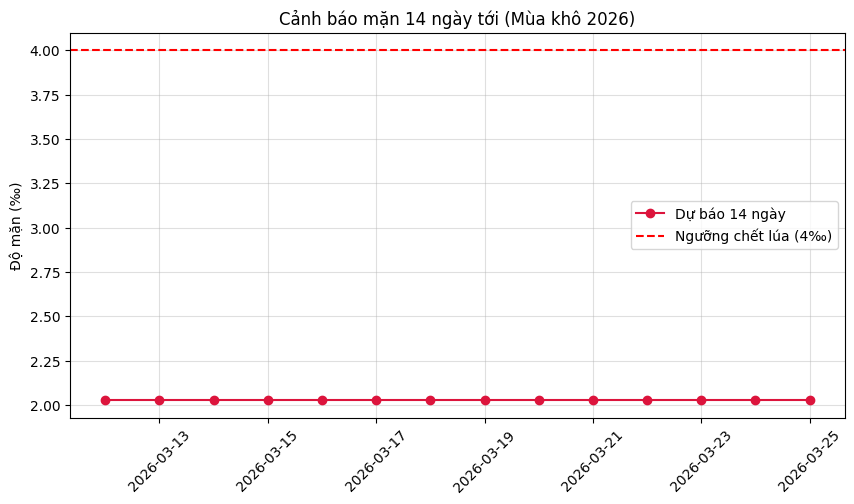

=> An toàn, mở cống bình thường


In [7]:
from datetime import timedelta

start_date = pd.to_datetime('2026-03-12')
days_to_predict = 14
future_dates = [start_date + timedelta(days=i) for i in range(days_to_predict)]
recent_wl = df_wl_daily[df_wl_daily['ObservationDate'] <= '2026-03-11']['WaterLevel_Mean'].tail(14).mean()

future_lags = [2.0] * 7
future_preds = []

for dt in future_dates:
    X_fut = pd.DataFrame([{
        'Lag_1D': future_lags[-1],
        'Lag_3D': future_lags[-3],
        'Lag_7D': future_lags[-7],
        'WaterLevel_Mean': recent_wl,
        'Month_sin': np.sin(2 * np.pi * dt.month / 12),
        'Month_cos': np.cos(2 * np.pi * dt.month / 12)
    }])
    pred = model_xgb.predict(X_fut)[0]
    future_preds.append(pred)
    future_lags.append(pred)

future_df = pd.DataFrame({'Date': future_dates, 'Salinity_Pred': future_preds}).set_index('Date')
plt.figure(figsize=(10, 5))
plt.plot(future_df.index, future_df['Salinity_Pred'], marker='o', color='crimson', label='Dự báo 14 ngày')
plt.axhline(4.0, color='red', linestyle='--', label='Ngưỡng chết lúa (4‰)')
plt.fill_between(future_df.index, 4.0, future_df['Salinity_Pred'].max() + 1, where=(future_df['Salinity_Pred'] > 4.0), color='red', alpha=0.3)
plt.title('Cảnh báo mặn 14 ngày tới (Mùa khô 2026)')
plt.ylabel('Độ mặn (‰)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.4)
plt.show()

ngay_nguy_hiem = future_df[future_df['Salinity_Pred'] > 4.0]
if len(ngay_nguy_hiem) > 0:
    print(f'Cảnh báo: Có {len(ngay_nguy_hiem)} ngày độ mặn > 4‰')
    print(f'=> Lệnh đóng cống từ {ngay_nguy_hiem.index[0].strftime("%d/%m/%Y")} đến {ngay_nguy_hiem.index[-1].strftime("%d/%m/%Y")}')
else:
    print('=> An toàn, mở cống bình thường')
